In the last notebook, we averaged the signals from all LFEs.  But we may want to sort the events into groups and just average within those groups.  Here we'll define one approach to grouping.

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Initialize and read detection info

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=156)

# and we need the LFE times
lf.read_detection_info()

In [3]:
# note that we now have the times of all LFEs in this family
print(lf.tms)
print(lf.tms.shape)

[UTCDateTime(2003, 2, 26, 14, 45, 28, 500000)
 UTCDateTime(2003, 3, 2, 1, 29, 8, 775000)
 UTCDateTime(2003, 3, 2, 18, 45, 51, 900000) ...
 UTCDateTime(2013, 10, 5, 0, 6, 37, 700000)
 UTCDateTime(2013, 10, 7, 0, 37, 32, 950000)
 UTCDateTime(2013, 10, 10, 6, 24, 43, 75000)]
(1658,)


In [4]:
# and the times of all LFEs, including all families
print(lf.atms)
print(lf.atms.shape)

[UTCDateTime(2003, 2, 28, 5, 52, 27, 900000)
 UTCDateTime(2003, 3, 2, 16, 24, 26, 150000)
 UTCDateTime(2003, 3, 2, 22, 16, 58, 875000) ...
 UTCDateTime(2013, 10, 2, 23, 11, 3, 875000)
 UTCDateTime(2013, 10, 4, 1, 40, 58, 300000)
 UTCDateTime(2013, 10, 5, 3, 27, 29, 200000)]
(213811,)


### 2. Note the large slow slip events

To group, we may first note that the LFEs are grouped into slow slip events.  In Cascadia, slow slip events (aka SSEs) last about a month and occur around once a year.  We can identify slow slip events just by noting when there's a large gap between LFEs.

In [5]:
# identify the times
lf.identify_sse_times()

In [6]:
# we've now created two variables

# the number of SSEs
print(lf.Nsse)

# and the time ranges of these events
print(lf.sse_tlms.shape)

10
(10, 2)


If you're working somewhere where there isn't a large gap between slow slip events and lf.identify_sse_times wouldn't work, you could define lf.sse_times and lf.Nsse manually.

### 3. Compute LFE rates as a function of time

Next, we'd like to know how the number of LFEs per minute or hour changes over the course of a slow slip event.


[UTCDateTime(2003, 2, 25, 2, 30) UTCDateTime(2003, 2, 25, 3, 45)
 UTCDateTime(2003, 2, 25, 5, 0) ... UTCDateTime(2013, 10, 13, 18, 30)
 UTCDateTime(2013, 10, 13, 19, 45) UTCDateTime(2013, 10, 13, 21, 0)]
[0. 0. 0. ... 0. 0. 0.]


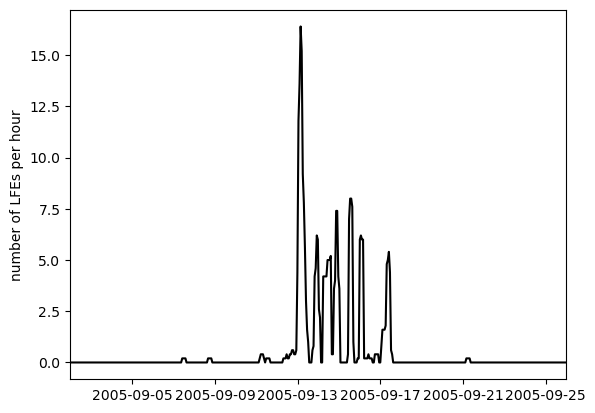

In [7]:
# here, compute the number of LFEs per 5-hour period
lf.compute_lfe_rates(bin_duration=5*3600)

# the centres of the time windows considered are in lf.tcent
print(lf.tcent)

# and the rates (per hour) are in lf.lferate
print(lf.lferate)

plt.plot_date(lf.tcent,lf.lferate,fmt='black',marker='none',linestyle='-')
plt.xlim(lf.sse_tlms[2,:]);
plt.ylabel('number of LFEs per hour');

### 3. Group LFEs within a slow slip event

We may wish to identify LFEs that occur early in a slow slip event vs later in a slow slip event---at least within a family.



In [8]:
# to do so, we first determine a family "start time": 
# here the time when the LFE rate reaches half the maximum LFE rate
lf.select_start_times()

# and then group the events by time since the start time
# here we have two groups: 0-0.75 days since the start time and 0.75-3 days since the start time
lf.group_events_bytime(tsplits=[0,0.75,3])

In [9]:
# we now have a dictionary 
print(lf.groups)

# here there are two groups: 'early' and 'late'
# the integers listed are the indices of the events in each group, 
# so the times of LFEs in the early group are
print(lf.tms[lf.groups['early']])

{'early': array([   4,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,
         15,   16,   17,   18,   19,   20,   21,   22,   23,   24,   25,
         26,   27,   28,   29,   30,   31,   32,   33,   34,   35,   36,
         37,   38,   39,   40,   41,   42,   43,   44,   45,   46,   47,
         48,   49,   50,   51,   52,   53,   54,   55,   56,   57,   58,
         59,   60,   61,   62,   63,   64,   65,   66,   67,   68,   69,
         70,   71,   72,   73,   74,   75,   76,   77,   78,   79,   80,
         81,   82,   83,   84,   85,   86,   87,   88,   89,   90,   91,
         92,   93,   94,   95,   96,   97,   98,   99,  100,  101,  102,
        103,  104,  105,  106,  107,  108,  109,  110,  111,  112,  225,
        226,  227,  228,  229,  230,  231,  232,  233,  234,  235,  236,
        237,  238,  239,  240,  241,  242,  243,  244,  245,  246,  247,
        248,  249,  250,  251,  252,  253,  254,  255,  256,  257,  258,
        259,  260,  261,  262,  263,  264

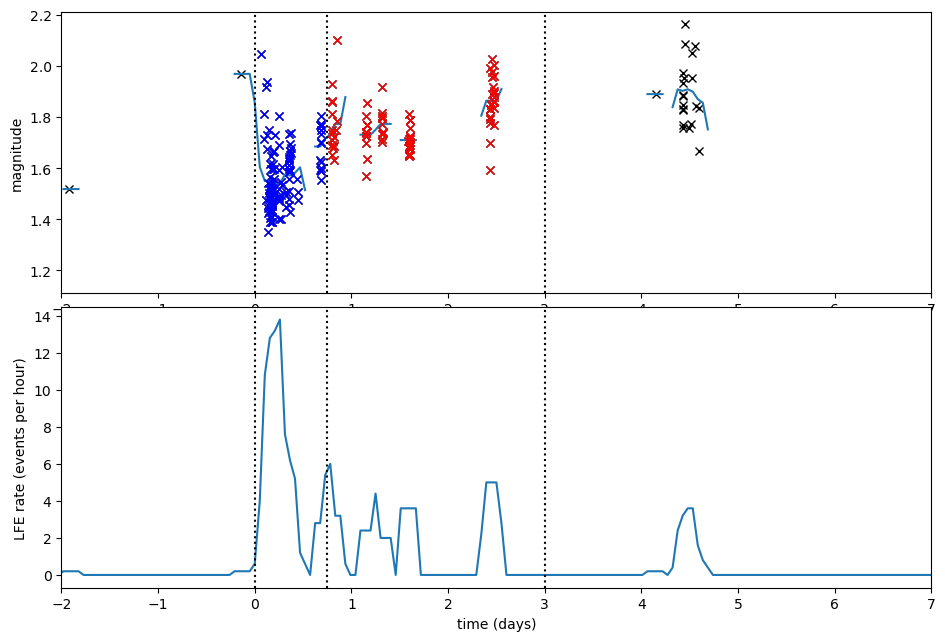

In [10]:
# it may be useful to plot the LFE properties and the LFE rate through time during an SSE
lf.plot_rate(iev=2003)